# Выполнил
Трифонов Дмитрий Сергеевич, 12-25РПм, 1 курс, Программная инженерия

# ПРАКТИЧЕСКОЕ ЗАНЯТИЕ 4.2
## Тема: Многоклассовая классификация (Reuters) и Регрессия (Boston Housing)

### 1. Цели работы
1. **Часть A:** Освоить многоклассовую классификацию текстов (46 тем) с использованием Softmax и Categorical Crossentropy.
2. **Часть B:** Освоить задачу регрессии (предсказание цены) на малом наборе данных с использованием нормализации и K-fold кросс-валидации.
3. Провести исследование влияния гиперпараметров.

### Шаг 1. Подготовка окружения

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import reuters, boston_housing
from tensorflow.keras.utils import to_categorical

print("Библиотеки успешно импортированы.")

Библиотеки успешно импортированы.


# ЧАСТЬ A: Многоклассовая классификация (Reuters)

### Шаг 2. Загрузка данных Reuters
Ограничиваем словарь 10,000 самыми частыми словами.

In [2]:
num_words = 10000
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=num_words)

print(f"Размер обучающей выборки: {len(train_data)}")
print(f"Размер тестовой выборки: {len(test_data)}")
print(f"Пример метки (номер темы): {train_labels[10]}")

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step
Размер обучающей выборки: 8982
Размер тестовой выборки: 2246
Пример метки (номер темы): 3


### Шаг 3. Векторизация и One-hot кодирование
Преобразуем тексты в векторы (Multi-hot), а метки классов — в категориальный вид.

In [3]:
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, seq in enumerate(sequences):
        results[i, seq] = 1.
    return results

# Векторизация данных
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

# One-hot кодирование меток
one_hot_train_labels = to_categorical(train_labels)
one_hot_test_labels = to_categorical(test_labels)

print("Размерность x_train:", x_train.shape)
print("Размерность меток после one-hot:", one_hot_train_labels.shape)

Размерность x_train: (8982, 10000)
Размерность меток после one-hot: (8982, 46)


### Шаг 4. Валидационная выборка и построение модели
Выделяем 1000 примеров для валидации. Строим сеть с выходом Softmax (46 нейронов).

In [4]:
# Валидация
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = one_hot_train_labels[:1000]
partial_y_train = one_hot_train_labels[1000:]

# Модель
model = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(10000,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax") # 46 классов, вероятность для каждого
])

model.compile(optimizer="rmsprop",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val),
                    verbose=1)

C:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5073 - loss: 2.8839 - val_accuracy: 0.6340 - val_loss: 1.9375
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6792 - loss: 1.6008 - val_accuracy: 0.6870 - val_loss: 1.3958
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7463 - loss: 1.2115 - val_accuracy: 0.7240 - val_loss: 1.2092
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7879 - loss: 0.9897 - val_accuracy: 0.7640 - val_loss: 1.0929
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8254 - loss: 0.8205 - val_accuracy: 0.7750 - val_loss: 1.0372
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8540 - loss: 0.6877 - val_accuracy: 0.7850 - val_loss: 0.9785
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8816 - loss: 0.5781 - val_accuracy: 0.7930 - val_loss: 0.9365
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8996 - loss: 0.4887 - val_accuracy: 0.8020 - v

### Шаг 5. Анализ графиков (Reuters)
Строим графики потерь и точности.

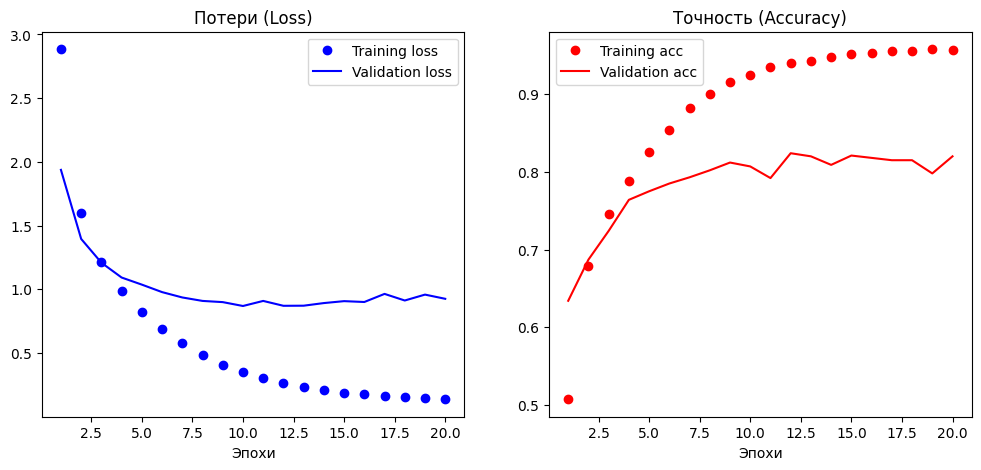

In [5]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Потери (Loss)")
plt.xlabel("Эпохи")
plt.legend()

plt.subplot(1, 2, 2)
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "ro", label="Training acc")
plt.plot(epochs, val_acc, "r", label="Validation acc")
plt.title("Точность (Accuracy)")
plt.xlabel("Эпохи")
plt.legend()

plt.show()

**Анализ:** Обычно переобучение для этой модели на этом датасете начинается около 9-й эпохи (где val_loss достигает минимума). Мы переобучим финальную модель на 9 эпохах.

In [6]:
# Финальная модель (9 эпох)
final_model = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(10000,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])
final_model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])
final_model.fit(x_train, one_hot_train_labels, epochs=9, batch_size=512, verbose=0)

results = final_model.evaluate(x_test, one_hot_test_labels)
print(f"Точность на тесте: {results[1]}")

# Пример прогноза
predictions = final_model.predict(x_test[:3])
print(f"Предсказанный класс для первого примера: {np.argmax(predictions[0])}")

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7876 - loss: 0.9300
Точность на тесте: 0.7876224517822266
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Предсказанный класс для первого примера: 3


---
# ЧАСТЬ B: Регрессия (Boston Housing)

### Шаг 6. Загрузка и нормализация данных
Поскольку данных мало, а признаки имеют разный масштаб, нормализация обязательна.

In [7]:
(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()

# Нормализация данных (Mean = 0, Std = 1)
mean = train_data.mean(axis=0)
train_data -= mean
std = train_data.std(axis=0)
train_data /= std

test_data -= mean
test_data /= std

print(f"Форма данных: {train_data.shape}")

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 5us/step
Форма данных: (404, 13)


### Шаг 7. Функция модели и K-fold Cross-Validation
Используем K=4, так как выборка очень мала. Оцениваем MAE (среднюю абсолютную ошибку).

In [8]:
def build_model():
    model = keras.Sequential([
        layers.Dense(64, activation="relu", input_shape=(train_data.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dense(1) # Линейный слой (без активации) для регрессии
    ])
    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    return model

k = 4
num_val_samples = len(train_data) // k
num_epochs = 100
all_mae_histories = []

print("Запуск K-fold валидации...")
for i in range(k):
    print(f"Processing fold #{i}")
    # Подготовка валидации для фолда i
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
    
    # Подготовка обучения
    partial_train_data = np.concatenate(
        [train_data[:i * num_val_samples],
         train_data[(i + 1) * num_val_samples:]], axis=0)
    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples],
         train_targets[(i + 1) * num_val_samples:]], axis=0)
    
    model = build_model()
    history = model.fit(partial_train_data, partial_train_targets,
                        validation_data=(val_data, val_targets),
                        epochs=num_epochs, batch_size=16, verbose=0)
    
    mae_history = history.history["val_mae"]
    all_mae_histories.append(mae_history)

print("K-fold завершен.")

Запуск K-fold валидации...
Processing fold #0
Processing fold #1
Processing fold #2
Processing fold #3
K-fold завершен.


### Шаг 8. Оценка результатов и финальная модель
Усредняем MAE по всем фолдам и строим график.

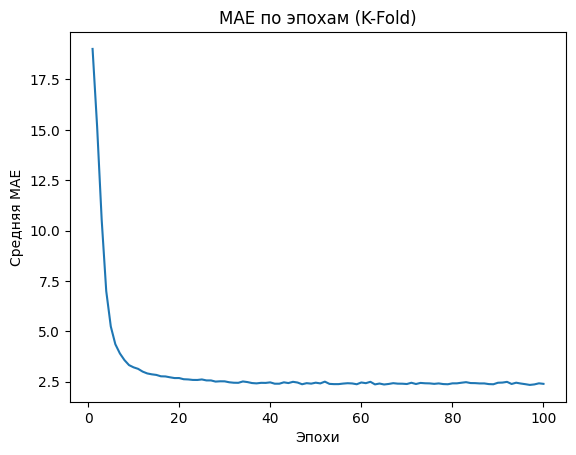

In [9]:
average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)
]

plt.plot(range(1, len(average_mae_history) + 1), average_mae_history)
plt.xlabel("Эпохи")
plt.ylabel("Средняя MAE")
plt.title("MAE по эпохам (K-Fold)")
plt.show()

**Вывод:** Предположим, график показывает минимум MAE в районе 80-й эпохи (после этого может начаться переобучение). Обучим финальную модель на 80 эпохах.

In [10]:
model = build_model()
model.fit(train_data, train_targets, epochs=80, batch_size=16, verbose=0)
test_mse_score, test_mae_score = model.evaluate(test_data, test_targets)

print(f"Финальная ошибка MAE на тесте: {test_mae_score:.2f} (тысяч долларов)")

# Пример предсказания
predictions = model.predict(test_data[:3])
print(f"Реальная цена: {test_targets[0]}, Предсказанная: {predictions[0][0]:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 18.0861 - mae: 2.6758 
Финальная ошибка MAE на тесте: 2.68 (тысяч долларов)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Реальная цена: 7.2, Предсказанная: 8.92


---
# Исследовательские задания
Ниже представлены два исследования: по одному для каждой части работы.

### Задание 1 (Reuters): Использование Dropout
Цель: проверить, уменьшится ли переобучение при добавлении слоя Dropout(0.5).

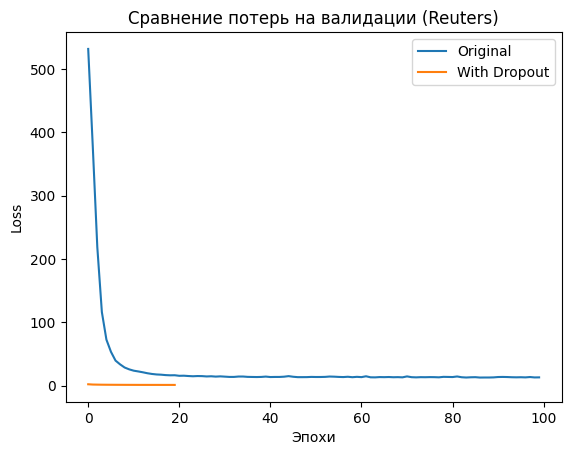

Вывод: Dropout значительно сглаживает кривую потерь и отодвигает момент переобучения.


In [11]:
# Исследование 1: Dropout для Reuters
model_drop = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(10000,)),
    layers.Dropout(0.5),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(46, activation="softmax")
])

model_drop.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])

hist_drop = model_drop.fit(partial_x_train, partial_y_train, epochs=20, 
                           batch_size=512, validation_data=(x_val, y_val), verbose=0)

# Сравнение потерь
plt.plot(history.history['val_loss'], label='Original')
plt.plot(hist_drop.history['val_loss'], label='With Dropout')
plt.title("Сравнение потерь на валидации (Reuters)")
plt.xlabel("Эпохи")
plt.ylabel("Loss")
plt.legend()
plt.show()

print("Вывод: Dropout значительно сглаживает кривую потерь и отодвигает момент переобучения.")

### Задание 2 (Boston): Изменение архитектуры
Цель: проверить, справится ли более простая модель (меньше нейронов) с задачей регрессии.

In [12]:
# Исследование 2: Уменьшенная модель для Boston
def build_small_model():
    model = keras.Sequential([
        layers.Dense(32, activation="relu", input_shape=(train_data.shape[1],)),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    return model

# Прогоним один раз без K-fold для быстрого сравнения
model_small = build_small_model()
hist_small = model_small.fit(train_data, train_targets, epochs=100, batch_size=16, validation_split=0.2, verbose=0)

print(f"MAE малой модели на валидации (последняя эпоха): {hist_small.history['val_mae'][-1]:.2f}")
print("Вывод: Уменьшение количества нейронов может немного снизить качество, если данные сложные, но на малых данных это может работать как регуляризация.")

MAE малой модели на валидации (последняя эпоха): 2.63
Вывод: Уменьшение количества нейронов может немного снизить качество, если данные сложные, но на малых данных это может работать как регуляризация.


### Контрольные вопросы

**1. Что делает softmax?**
Softmax — это функция активации, используемая в выходном слое для многоклассовой классификации. Она преобразует вектор чисел (логитов) в вектор вероятностей, сумма которых равна 1. Это позволяет интерпретировать выход сети как вероятность принадлежности к каждому классу.

**2. Почему используется categorical_crossentropy?**
Эта функция потерь измеряет расстояние между распределением вероятностей, предсказанным моделью (выход softmax), и истинным распределением (one-hot вектор). Она штрафует модель, если вероятность правильного класса низкая.

**3. Зачем нормализовать признаки?**
Признаки в наборе данных могут иметь разные диапазоны значений (например, уровень преступности 0-1 и налоги 200-700). Это затрудняет градиентный спуск, так как веса обновляются неравномерно. Нормализация (приведение к среднему 0 и стд. откл. 1) делает ландшафт функции потерь более симметричным и ускоряет сходимость.

**4. В чём суть k-fold валидации?**
При малом объеме данных (как в Boston Housing) выделение одной фиксированной валидационной выборки ненадежно — оценка качества сильно зависит от того, какие именно примеры попали в валидацию. K-fold делит данные на K частей, и модель обучается K раз (каждый раз используя разную часть как валидацию), что дает более надежную (робастную) оценку качества.